PRACTICA DE ALIASING Y MOIRE

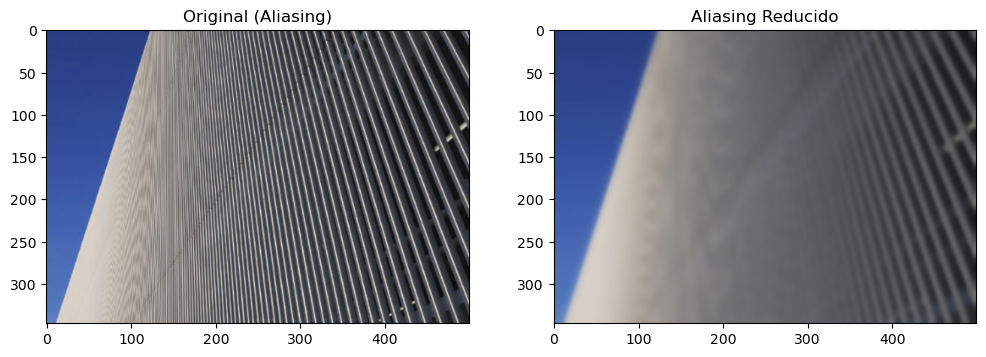

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def anti_aliasing_avanzado(img):

    blur = cv2.GaussianBlur(img, (9,9), 2.5)

    bilateral = cv2.bilateralFilter(blur, 15, 120, 120)

    h, w = bilateral.shape[:2]
    
    down = cv2.resize(bilateral, (w//3, h//3), interpolation=cv2.INTER_AREA)
    up = cv2.resize(down, (w, h), interpolation=cv2.INTER_CUBIC)

    return up

img = cv2.imread('Aliasing.jpg')

img_procesada = anti_aliasing_avanzado(img)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original (Aliasing)")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_procesada, cv2.COLOR_BGR2RGB))
plt.title("Aliasing Reducido")

plt.show()

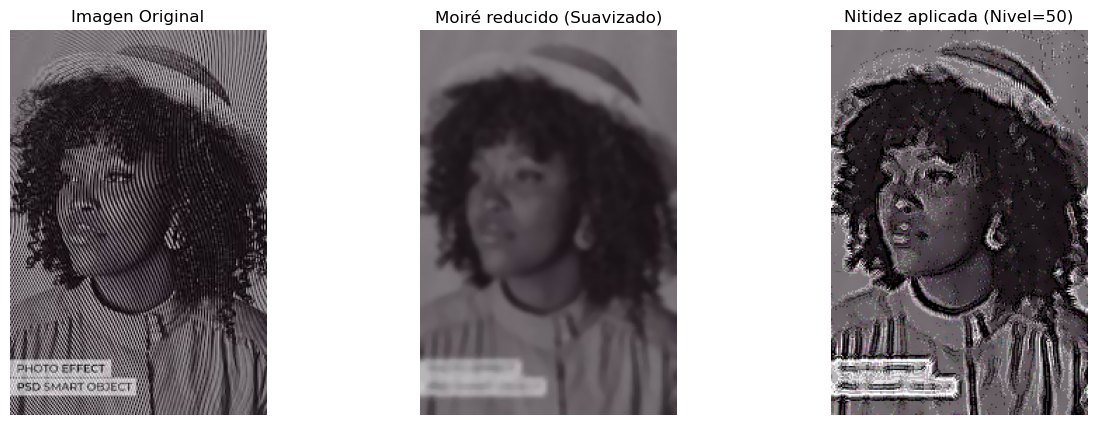

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def eliminar_moire(imagen):
    gaussian = cv2.GaussianBlur(imagen, (7,7), 2)
    median = cv2.medianBlur(gaussian, 5)
    return median


def aplicar_nitidez(imagen, nivel=1.5):
    blur = cv2.GaussianBlur(imagen, (3,3), 0)
    nitida = cv2.addWeighted(imagen, 1 + nivel, blur, -nivel, 0)
    return nitida


img = cv2.imread('moire.jpg')

img_sin_moire = eliminar_moire(img)

nivel_nitidez = 50
img_nitida = aplicar_nitidez(img_sin_moire, nivel_nitidez)


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_sin_moire, cv2.COLOR_BGR2RGB))
plt.title("Moiré reducido (Suavizado)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_nitida, cv2.COLOR_BGR2RGB))
plt.title(f"Nitidez aplicada (Nivel={nivel_nitidez})")
plt.axis("off")

plt.show()